# Imports

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 
import scanpy as sc
import warnings
import scanpy as sc
import anndata as ad
import os
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

main_dir = '../'
# task_grn_inference_dir = '../../'
output_dir = f"{main_dir}/output/"

# - local imports 
from ciim.src.tf_activity.helper import adata_lambda
from ciim.src.common import v_datasets, datasets, datasets_all, datasets_disease, cell_types, surrogate_names, colors_blind, palette_cell_types, palette_datasets, palette_datasets_pretty, palette_genders, palette_sub_types
from ciim.src.utils.plots import plot_umap

to_save = f'/vol/projects/jnourisa/datasets/umap/'
os.makedirs(to_save, exist_ok=True)

# ATAC

In [ ]:
adata = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data6_CMtx.h5ad')

# UMAP

## Single cell of all data

In [19]:
if False:
    lambda_sc_adata = lambda dataaset:  f'/vol/projects/jnourisa/datasets/{dataset}_raw.h5ad'
    for dataset in datasets:
        adata = ad.read_h5ad(lambda_sc_adata(dataset))
        adata.obs['Major_CT'].dropna(inplace=True)
        adata = adata[adata.obs['Major_CT'].isin(cell_types)]
        adata.obs['Major_CT'] = pd.Categorical(adata.obs['Major_CT'], categories=cell_types, ordered=True)

        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, n_top_genes=2000)

        sc.pp.pca(adata, use_highly_variable=True)  
        sc.pp.neighbors(adata, n_neighbors=15)  
        sc.tl.umap(adata)  
        adata.write(f'{to_save}/{dataset}_umap.h5ad')
else:
    adata_dict = {}
    for dataset in datasets:
        adata = ad.read_h5ad(f'{to_save}/{dataset}_umap.h5ad')
        adata_dict[dataset] = adata

KeyboardInterrupt: 

In [7]:
adata1 = adata_dict[datasets[0]]
adata2 = adata_dict[datasets[1]]

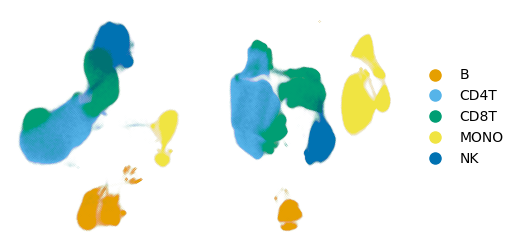

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(5, 3))
ax = axes[0]
plot_umap(adata1, color='Major_CT', ax=ax, s=.002, X_label='X_umap', alpha=0.1, palette=palette_cell_types)  
ax.get_legend().remove()
ax = axes[1]
plot_umap(adata2, color='Major_CT', ax=ax, s=.002, X_label='X_umap', alpha=0.1, palette=palette_cell_types) 
plt.savefig(f'{output_dir}/umap.png', bbox_inches='tight', dpi=300)

## Single cell of sub types

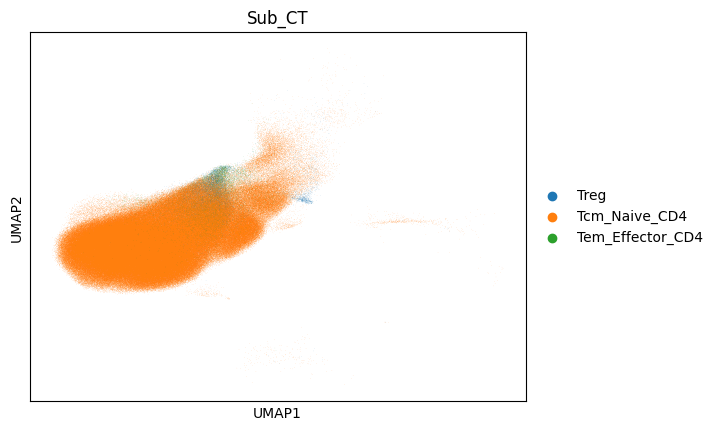

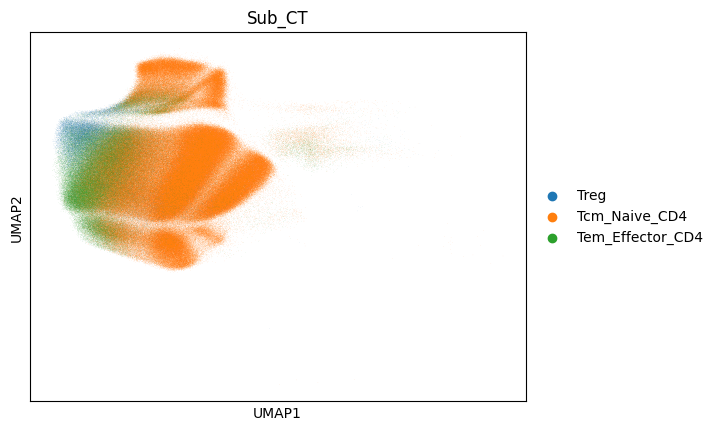

In [22]:
cell_type = 'CD4T'
adata1_sub = adata1[adata1.obs['Major_CT']==cell_type]
# fig, ax = plt.subplots(1, 1, figsize=(5, 5))
# plot_umap(adata1_sub, color='Sub_CT', ax=ax, s=.1, X_label='X_pca', alpha=0.1, palette=palette_sub_types)  
sc.pl.umap(adata1_sub, color='Sub_CT')

adata2_sub = adata2[adata2.obs['Major_CT']==cell_type]
# fig, ax = plt.subplots(1, 1, figsize=(5, 5))
# plot_umap(adata2_sub, color='Sub_CT', ax=ax, s=.1, X_label='X_pca', alpha=0.1, palette=palette_sub_types)  
sc.pl.umap(adata2_sub, color='Sub_CT')

## Bulk data

IndexError: index 4 is out of bounds for axis 0 with size 4

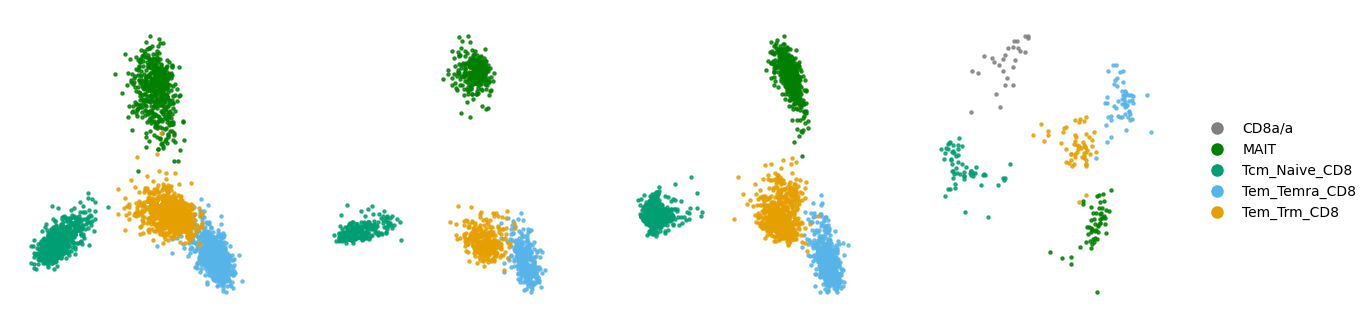

In [ ]:
os.makedirs('../output/temp/umap/', exist_ok=True)
run_umap = False

for j, cell_type in enumerate(['CD8T', 'CD4T', 'MONO']):
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    for i, dataset in enumerate(datasets+v_datasets):
        ax = axes[i]
        if run_umap:
            adata = ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_bulk_minor.h5ad', backed='r')
            adata = adata[adata.obs['Major_CT'] == cell_type].to_memory()
            sc.pp.highly_variable_genes(adata, n_top_genes=2000)
            sc.pp.pca(adata, use_highly_variable=True)  
            sc.pp.neighbors(adata, n_neighbors=15)  
            sc.tl.umap(adata) 
            adata.write(f'../output/temp/umap/{cell_type}_{dataset}_bulk_minor.h5ad')
        else:
            adata = ad.read_h5ad(f'../output/temp/umap/{cell_type}_{dataset}_bulk_minor.h5ad')
        plot_umap(adata, color='Sub_CT', ax=ax, s=5, X_label='X_pca', alpha=0.8, palette=palette_sub_types) 
        # sc.pl.umap(adata, color='Sub_CT', ax=ax, palette=palette_sub_types)
        
        if i != len(axes)-1:
            ax.get_legend().remove()
    # plt.tight_layout()

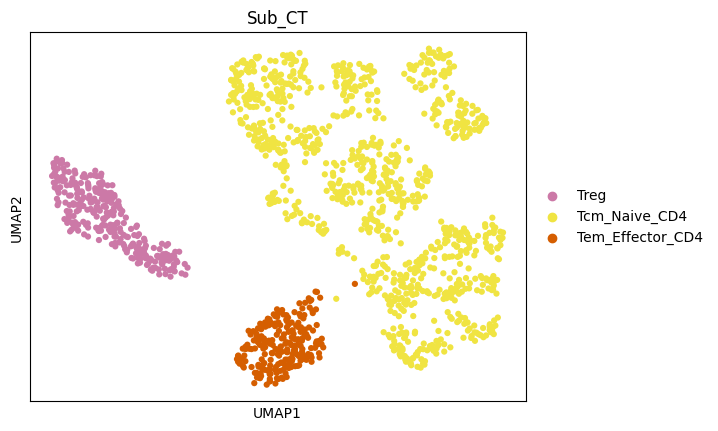

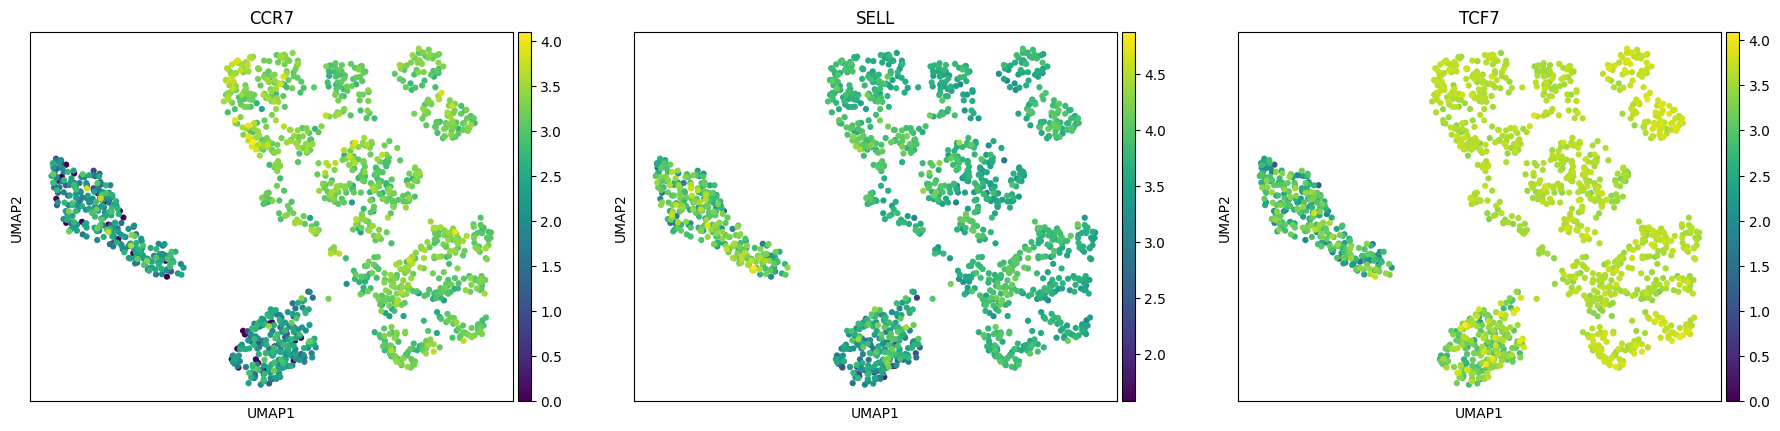

In [55]:

for j, cell_type in enumerate(['CD4T']):
    for i, dataset in enumerate(datasets[0:1]):
        adata = ad.read_h5ad(f'../output/temp/umap/{cell_type}_{dataset}_bulk_minor.h5ad')
        # plot_umap(adata, color='Sub_CT', ax=ax, s=1, X_label='X_pca', alpha=0.8, palette=palette_sub_types) 
        sc.pl.umap(adata, color=['Sub_CT', ], palette=palette_sub_types)
        sc.pl.umap(adata, color=['CCR7', 'SELL', 'TCF7'], cmap='viridis') # tcm native
        # sc.pl.umap(adata, color=['FOXP3', 'IL2RA', 'CTLA4'], cmap='viridis') # treg 
        # sc.pl.umap(adata, color=['IFNG', 'RORC', 'TBX21'], cmap='viridis') # effector
        # sc.pl.umap(adata, color=['CD8B', 'S100B', 'CCR7', 'RGS10', 'NOSIP', 'LINC02446', 'LEF1', 'CRTAM', 'CD8A'], cmap='viridis') # naive
        # sc.pl.umap(adata, color=['CD8B', 'ANXA1', 'CD8A', 'KRT1', 'LINC02446', 'YBX3', 'IL7R', 'TRAC', 'NELL2', 'LDHB'], cmap='viridis') # tcm

# Cell count: pseudobulking

In [10]:
# from task_grn_inference.src.exp_analysis.helper import plot_cumulative_density
# fig, ax = plt.subplots(1, 1, figsize=(3, 3), sharey=True)
# for i, dataset in enumerate(par['datasets']):
#     adata = adata_lambda(dataset)
#     cell_count = adata.obs['cell_count']
#     plot_cumulative_density(cell_count, ax=ax, label=dataset)
#     ax.set_xlabel('Cell count')
#     ax.set_ylabel('Cumulative density')
#     ax.set_xscale('log')
# plt.legend(loc=(1, .5))

# Stats

In [2]:
data_store = []
for dataset in datasets_all:
    adata = adata_lambda(dataset)
    n_cells = adata.obs['cell_count'].sum()
    n_donors = adata.obs['donor_id'].nunique()
    n_age_donors = adata.obs['age_donor'].nunique()
    data_store.append({'Dataset': dataset, 'Genes': adata.n_vars, 'Donors': n_donors, 'Samples (donors * age)': n_age_donors, 'Cells': n_cells})
df = pd.DataFrame(data_store)
df['Dataset'] = df['Dataset'].map(surrogate_names)
df

,Dataset,Genes,Donors,Samples (donors * age),Cells
0,C1: European,17001,981,981,1247698
1,C2: European,24516,166,313,1916362
2,C3: European,17289,61,61,538264
3,C4: Korean,20536,165,165,367223
4,C4: Japanese,19613,148,148,286764
5,C5: SLE,18125,261,263,1263441


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


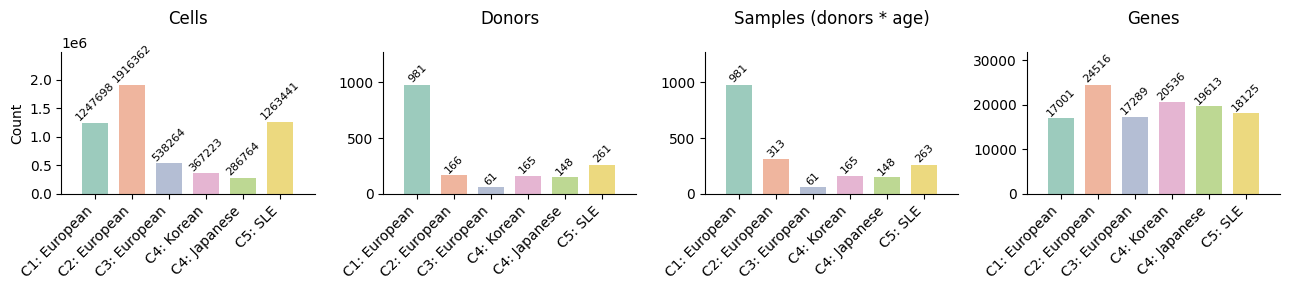

In [3]:
from ciim.src.common import palette_datasets

# Convert DataFrame to long format for easier plotting
df_long = df.melt(id_vars=["Dataset"], var_name="Metadata", value_name="Count")

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for i, metadata in enumerate(['Cells', 'Donors', 'Samples (donors * age)', 'Genes']):
    ax = axes[i]
    
    # Create bar plot
    sns.barplot(data=df, x='Dataset', y=metadata, alpha=.7, ax=ax, hue='Dataset', width=.7, palette=palette_datasets_pretty, legend=False)
    
    # Annotate bars with values (rotated 45 degrees)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2,  # X position
                p.get_height(),  # Y position (top of bar)
                f'{int(p.get_height())}',  # Text label
                ha='center', va='bottom', fontsize=8, rotation=45)  # Rotate 45 degrees

    # Formatting
    ax.set_title(metadata, pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(x=0.1, y=0.3)
    
    if i == 0:
        ax.set_ylabel("Count")
    else:
        ax.set_ylabel("")
    
    ax.set_xlabel("")
    ax.legend().remove()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

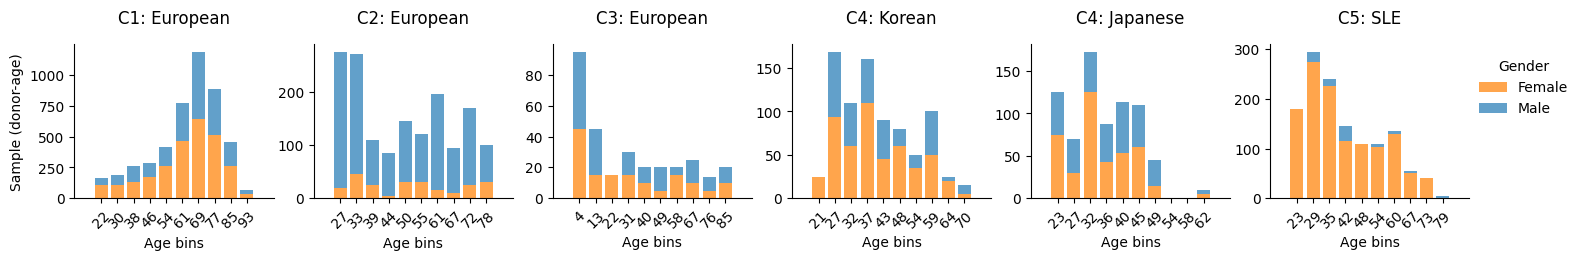

In [18]:

fig, axes = plt.subplots(1, len(datasets_all), figsize=(3*len(datasets_all), 2), sharey=False)

for i, dataset in enumerate(datasets_all):
    adata = adata_lambda(dataset)
    
    df = adata.obs.copy()
    df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))

    # Count occurrences of each sex within each age group
    df_count = df.groupby(['age', 'sex']).size().reset_index(name='count')

    # Pivot data for stacking
    df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)

    # Plot stacked bar chart
    df_pivot['binned'] = pd.cut(df_pivot.index, bins=10)  
    df_binned = df_pivot.groupby('binned').sum() 
    df_binned.plot(kind='bar', stacked=True, ax=axes[i], color=palette_genders, alpha=0.7, width=.8)


    axes[i].set_xlabel("Age bins")
    axes[i].set_ylabel("Sample (donor-age)" if i == 0 else "")  
    axes[i].set_title(surrogate_names[dataset], pad=15)
    bin_midpoints = [int(interval.mid) for interval in df_binned.index.categories]
    axes[i].set_xticklabels(bin_midpoints)

    # Set x-axis ticks
    # axes[i].set_xticks(bin_midpoints)
    # Adjust xticks to show fewer labels
    # xtick_labels = [int(float(label.get_text())) for label in ]
    # step = max(1, len(xtick_labels) // 5)  # Show ~5 evenly spaced labels
    # axes[i].set_xticks(range(0, len(xtick_labels), step))
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    x_min, x_max = axes[i].get_xlim()
    axes[i].set_xlim(x_min - 1, x_max + 1) 
    
    axes[i].get_legend().remove()
axes[i].legend(loc=(1.02, .5), frameon=False, title='Gender')

plt.show()

## Metadata donut plot

In [12]:
adata_dict = {}
for dataset in datasets_all+datasets_disease:
    adata = adata_lambda(dataset)
    if 'race' not in adata.obs.columns:
        adata.obs['race'] = 'European'
    if 'disease' not in adata.obs.columns:
        adata.obs['disease'] = 'Healthy'
    adata.obs['disease'] = adata.obs['disease'].apply(lambda name: surrogate_names.get(name, name))
    adata.obs['sex'] = adata.obs['sex'].apply(lambda name: {'F':'Female', 'M': 'Male'}.get(name, name))
    dataset_name = surrogate_names.get(dataset, dataset)
    adata_dict[dataset_name] = adata

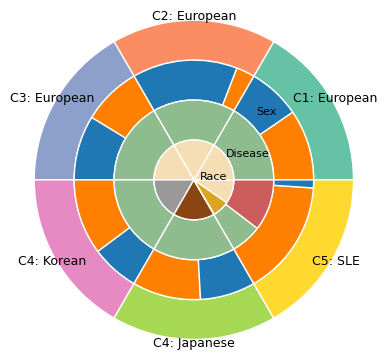

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def summarize_metadata_all(adata_dict, fields):
    """
    Extract and store metadata summaries from multiple AnnData objects.
    Returns a dict of dicts: {field: {dataset_name: value_counts Series}}
    """
    all_summaries = {field: {} for field in fields}
    for dataset_name, adata in adata_dict.items():
        for field in fields:
            if field in adata.obs.columns:
                counts = adata.obs[field].value_counts().sort_index()
                all_summaries[field][dataset_name] = counts
    return all_summaries

def plot_multi_ring_pie_by_dataset(summary_dict, colors_dict=None):
    """
    Plot a multi-ring pie chart with dataset as the outermost ring.
    Each inner ring corresponds to a metadata field (e.g., sex, disease).
    """
    fig, ax = plt.subplots(figsize=(4, 4), subplot_kw=dict(polar=True))
    size = 0.3
    theta_offset = np.pi / 2

    datasets = list(next(iter(summary_dict.values())).keys())
    n_datasets = len(datasets)
    dataset_angle = 2 * np.pi / n_datasets
    dataset_positions = {ds: i * dataset_angle for i, ds in enumerate(datasets)}

    radius = 1.0

    # Outermost ring: datasets
    for ds, angle_start in dataset_positions.items():
        ax.bar(
            x=angle_start + dataset_angle / 2,
            height=size,
            width=dataset_angle,
            bottom=radius - size,
            color=palette_datasets_pretty[ds],
            edgecolor='white'
        )
        ax.text(angle_start + dataset_angle / 2, radius + 0.03, ds, ha='center', va='center', fontsize=9, rotation=0)

    radius -= size

    # Inner rings: fields (sex, race, etc.)
    i_field = 0
    for field, field_data in summary_dict.items():
        for ds, angle_start in dataset_positions.items():
            counts = field_data.get(ds, pd.Series())
            total = counts.sum()
            if total == 0:
                continue

            rel_angles = 2 * np.pi * counts.values / (total * n_datasets)
            start = angle_start

            for label, angle in zip(counts.index, rel_angles):
                color = colors_dict.get(label, '#d3d3d3') if colors_dict else None
                ax.bar(
                    x=start + angle / 2,
                    height=size,
                    width=angle,
                    bottom=radius - size,
                    color=color,
                    edgecolor='white',
                    linewidth=1
                )
                start += angle

        # Optional: label for each ring
        ax.text(radius+.05, radius - 0.15, field.capitalize(), ha='center', va='center', fontsize=8,
                bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.3'))

        radius -= size
        i_field += 1
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


# Define fields and colors
fields = ['sex', 'disease', 'race']
colors_dict = {
    **palette_genders, **palette_datasets_pretty, 
    
    **{'European': '#F5DEB3', 'Japanese': '#8B4513', 'Asian': '#DAA520', 'Korean': '#999999',
    'Healthy': '#8FBC8F', 'SLE': '#CD5C5C', 'Control': '#8FBC8F'}
}

# Example usage
all_summaries = summarize_metadata_all(adata_dict, fields)
plot_multi_ring_pie_by_dataset(all_summaries, colors_dict)

C1: European 1.0471975511965976
C2: European 2.0943951023931953
C3: European 3.141592653589793
C4: Korean 4.1887902047863905
C4: Japanese 5.235987755982988
C5: SLE 6.283185307179586


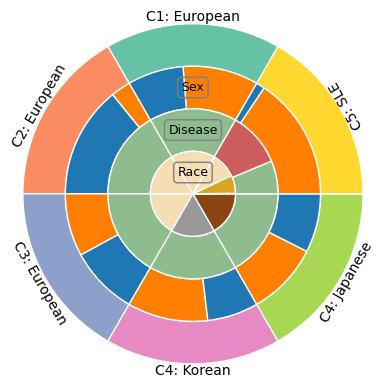

In [45]:
def plot_multi_ring_pie_by_dataset(summary_dict, colors_dict=None):
    """
    Plot a multi-ring pie chart with dataset as the outermost ring.
    Each inner ring corresponds to a metadata field (e.g., sex, disease),
    and the center is left empty with labels placed at the outer end of each ring.
    """
    fig, ax = plt.subplots(figsize=(4, 4), subplot_kw=dict(polar=True))
    size = 0.3
    theta_offset = np.pi / 2

    datasets = list(next(iter(summary_dict.values())).keys())
    n_datasets = len(datasets)
    dataset_angle = 2 * np.pi / n_datasets
    dataset_positions = {ds: (i+1) * dataset_angle for i, ds in enumerate(datasets)}

    radius = 1.0

    # Outermost ring: datasets
    for ds, angle_start in dataset_positions.items():
        ax.bar(
            x=angle_start + dataset_angle / 2,
            height=size,
            width=dataset_angle,
            bottom=radius - size,
            color=palette_datasets_pretty[ds],
            edgecolor='white'
        )
        print(ds, angle_start)
        if angle_start>3:
            rotation = np.degrees(angle_start + dataset_angle / 2 + np.pi/2)
        else:
            rotation = np.degrees(angle_start + dataset_angle / 2 - np.pi/2)
        ax.text(
            angle_start + dataset_angle / 2,
            radius + 0.05,
            ds,
            ha='center',
            va='center',
            fontsize=10,
            rotation=rotation,
            rotation_mode='anchor'
        )

    radius -= size

    # Inner rings: fields
    for field, field_data in summary_dict.items():
        for ds, angle_start in dataset_positions.items():
            counts = field_data.get(ds, pd.Series())
            total = counts.sum()
            if total == 0:
                continue

            rel_angles = 2 * np.pi * counts.values / (total * n_datasets)
            start = angle_start

            for label, angle in zip(counts.index, rel_angles):
                color = colors_dict.get(label, '#d3d3d3') if colors_dict else None
                ax.bar(
                    x=start + angle / 2,
                    height=size,
                    width=angle,
                    bottom=radius - size,
                    color=color,
                    edgecolor='white',
                    linewidth=1
                )
                start += angle

        # Label at the outer edge of the ring (same angle for all)
        ax.text(
            np.pi/2,  # top
            radius - size / 2,
            field.capitalize(),
            ha='center',
            va='center',
            fontsize=9,
            bbox=dict(facecolor='none', edgecolor='gray', boxstyle='round,pad=0.3')
        )

        radius -= size

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
plot_multi_ring_pie_by_dataset(all_summaries, colors_dict)


In [23]:
all_summaries['data1']

{'sex': sex
 F    2695
 M    1998
 Name: count, dtype: int64,
 'disease': disease
 healthy    4694
 Name: count, dtype: int64,
 'race': race
 european    4694
 Name: count, dtype: int64}

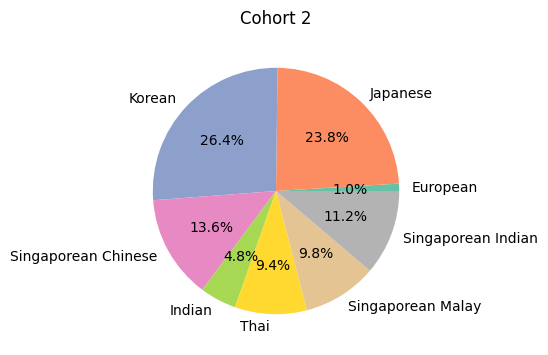

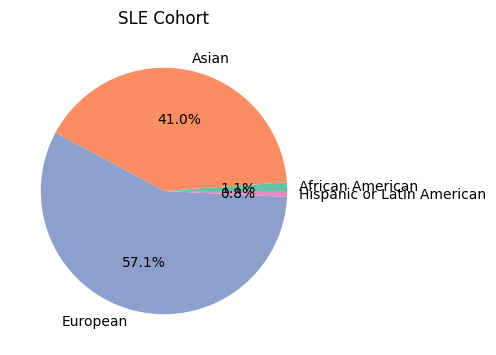

In [5]:
# Plot for each dataset
for dataset in ['data13', 'SLE']:
    if dataset == 'data13':
        adata = ad.read_h5ad(f'/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/{dataset}_CMtx.h5ad', backed='r')
    else:
        adata = adata_lambda(dataset)

    # Step 1: Get unique races and create color palette
    race_info = adata.obs.groupby('race')['donor_id'].nunique().reset_index(name='count')
    
    # Generate a color palette based on the number of unique races
    colors = sns.color_palette('Set2', n_colors=len(race_info))

    # Step 2: Plot the pie chart with the dynamically generated colors
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.pie(race_info['count'], labels=race_info['race'], autopct='%1.1f%%', colors=colors)
    plt.title(surrogate_names[dataset], pad=10)
    plt.show()

## Disease

Text(0.5, 1.0, 'SLE Cohort')

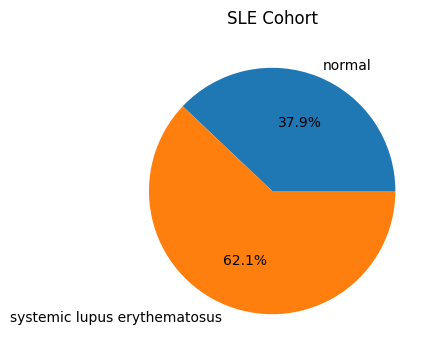

In [6]:
dataset = 'SLE'
adata = adata_lambda(dataset)
race_info = adata.obs.groupby('disease')['donor_id'].nunique().reset_index(name='count')
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
bb = ax.pie(race_info['count'], labels=race_info['disease'], autopct='%1.1f%%')
plt.title(surrogate_names[dataset], pad=10)

Text(0.5, 1.0, 'Covid Cohort')

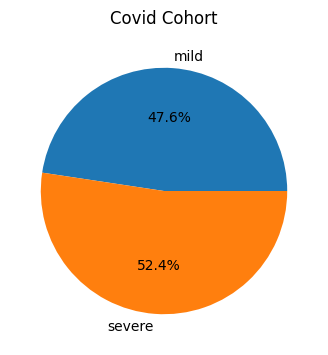

In [7]:
dataset = 'Covid_50MHH'
adata = adata_lambda(dataset)

race_info = adata.obs.groupby('Max_WHO_Group')['donor_id'].nunique().reset_index(name='count')
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
bb = ax.pie(race_info['count'], labels=race_info['Max_WHO_Group'], autopct='%1.1f%%')
plt.title(surrogate_names[dataset], pad=10)

In [8]:
adata.obs.groupby(['cell_type', 'Max_WHO_Group']).size()

cell_type  Max_WHO_Group
B          mild             20
           severe           22
CD4T       mild             20
           severe           22
CD8T       mild             20
           severe           22
MONO       mild             20
           severe           22
NK         mild             20
           severe           22
dtype: int64

## Subcell types rations

In [9]:
obs_dict = {dataset: ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_sc.h5ad', backed='r').obs for dataset in datasets_all}

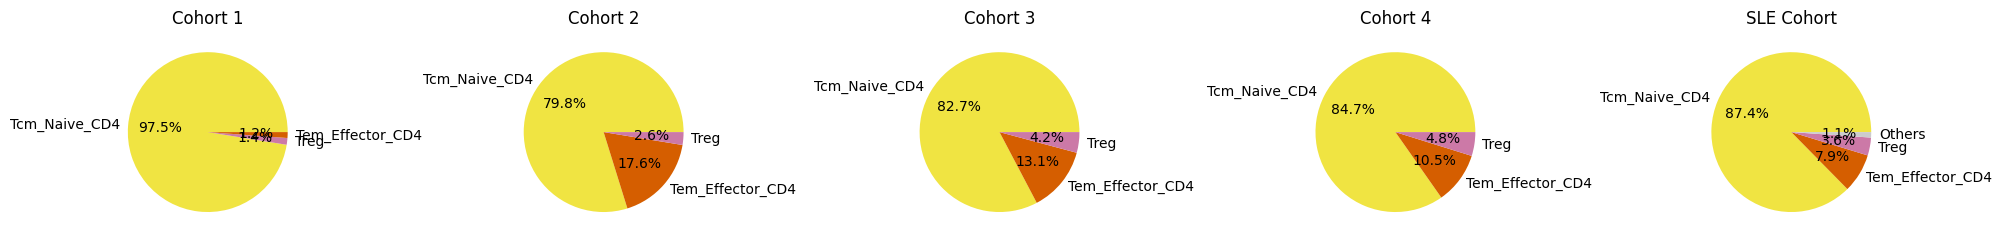

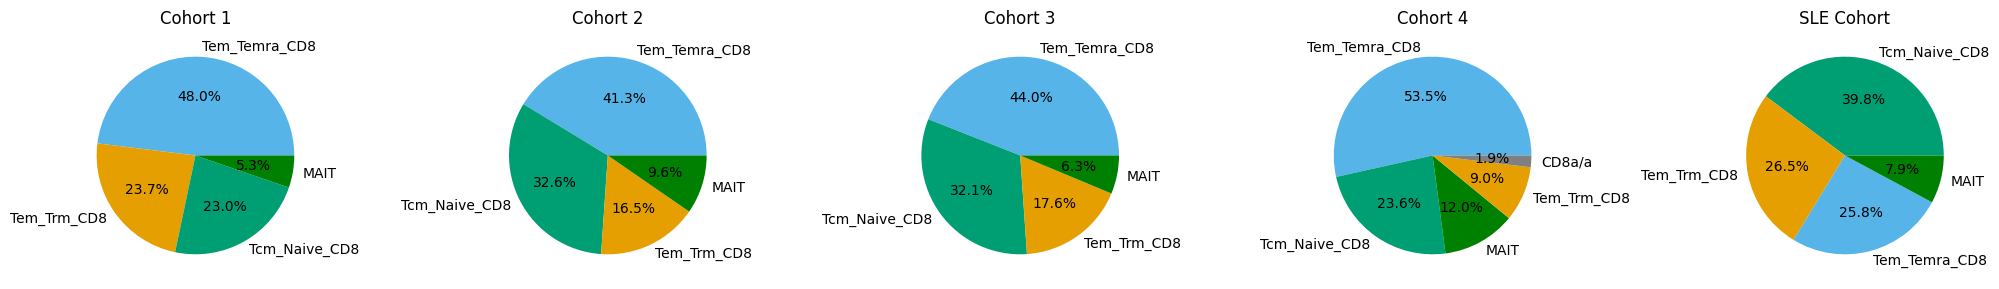

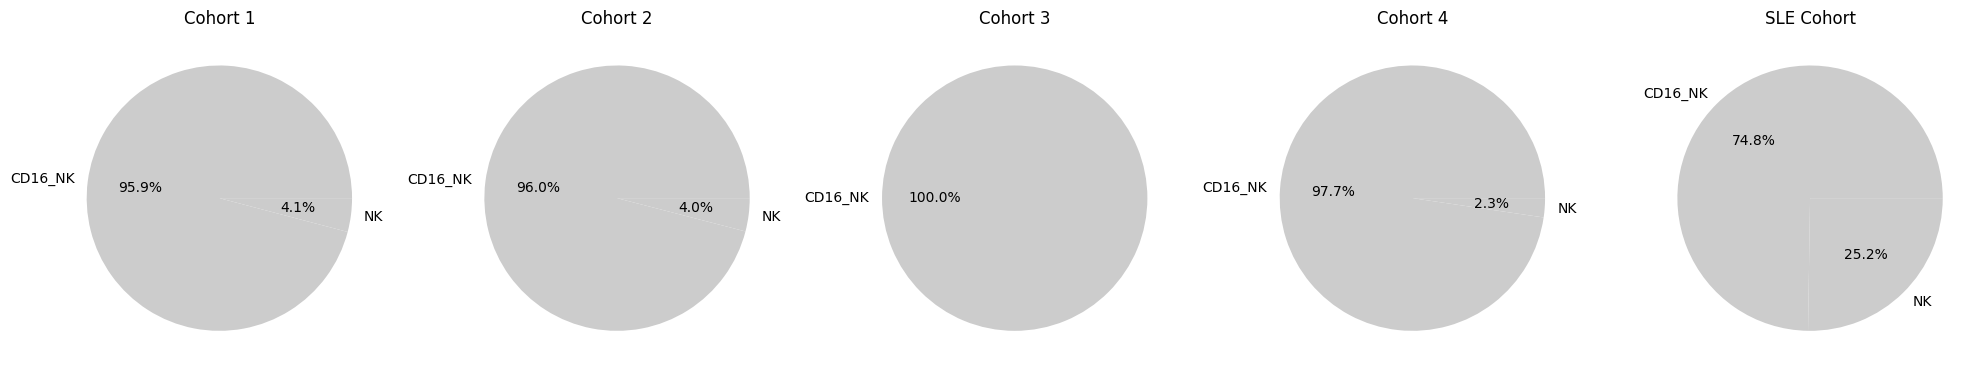

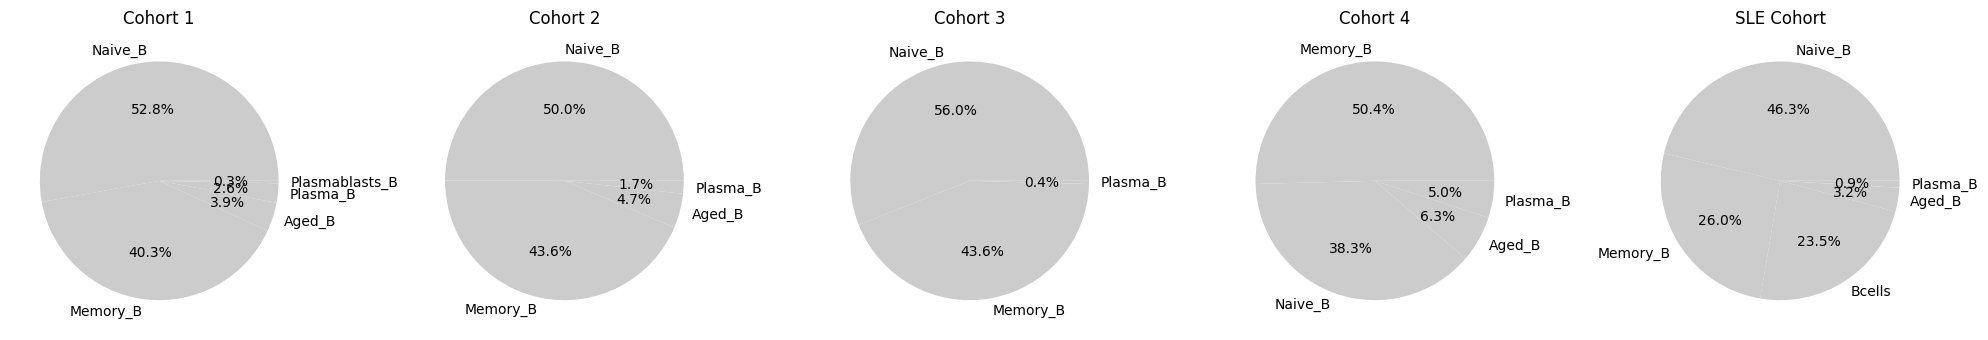

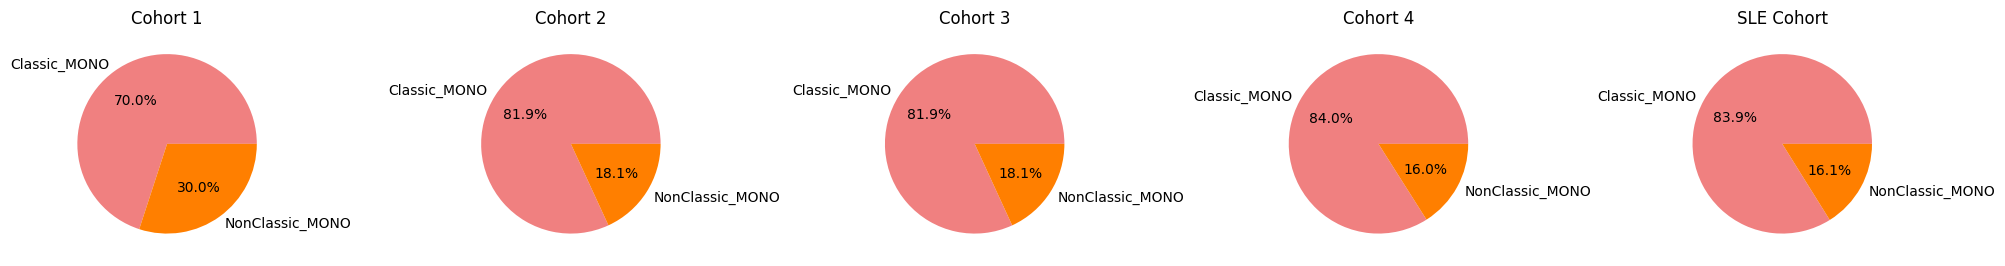

In [10]:
def pieplot(df, ax):
    """Create a pie chart with mapped colors."""
    df = df.to_frame(name='count')  # Convert Series to DataFrame
    df.index.name = 'cell_type'
    colors = [palette_sub_types[cell] if cell in palette_sub_types else "#cccccc" for cell in df.index]
    df.plot(kind='pie', y='count', autopct='%1.1f%%', colors=colors, ax=ax, legend=False)
    ax.set_ylabel('')
for j, cell_type in enumerate(cell_types):
    fig, axes = plt.subplots(1, len(datasets_all), figsize=(4*len(datasets_all), 4))
    for i, dataset in enumerate(datasets_all):
        obs = obs_dict[dataset]
        obs = obs[obs['Major_CT'] == cell_type]
        obs['Sub_CT'] = obs['Sub_CT'].astype(str)

        cell_type_counts = obs['Sub_CT'].value_counts()
        ax = axes[i]
        pieplot(cell_type_counts, ax)
        ax.set_title(surrogate_names[dataset])
    plt.tight_layout()

## Cell type frequency analysis

In [11]:
def calculate_freq(obs):
    # - calculate frequency 
    obs['Sub_CT'] = obs['Sub_CT'].astype(str)
    subct_counts = obs.groupby(['donor_id', 'Sub_CT']).size().reset_index(name='count')
    total_counts = obs.groupby('donor_id').size().reset_index(name='total')
    freq = subct_counts.merge(total_counts, on='donor_id')
    freq['ratio'] = freq['count'] / freq['total']
    metadata_cols = ['donor_id', 'age', 'age_group']
    metadata = obs[metadata_cols].drop_duplicates()
    freq = freq.merge(metadata, on='donor_id', how='left')
    return freq

freq_store = []
for j, cell_type in enumerate(cell_types):
    for i, dataset in enumerate(datasets_all):
        obs = obs_dict[dataset]
        obs = obs[obs['cell_type'] == cell_type]
        freq = calculate_freq(obs)
        freq['dataset'] = dataset
        freq_store.append(freq)
freq_df = pd.concat(freq_store)

In [12]:
# freq_df['dataset'].unique(), freq_df['Sub_CT'].unique(), freq_df['age_group'].unique()

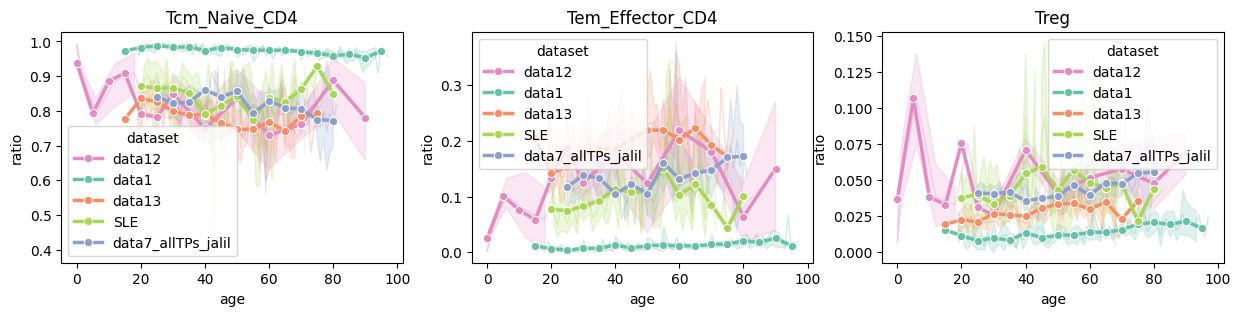

In [13]:
from ciim.src.common import mapping_major_2_minor
for j, cell_type in enumerate(['CD4T']):
    subtypes = mapping_major_2_minor[cell_type]
    fig, axes = plt.subplots(1, len(subtypes), figsize=(5*len(subtypes), 3))
    for i, subtype in enumerate(subtypes):
        ax = axes[i]
        freq = freq_df[freq_df['Sub_CT'] == subtype]
        freq['age_bin'] = (freq['age'] // 5 * 5).astype(int)  # e.g., 48 → 45, 53 → 50

        mean_ratio = (
            freq.groupby(['age_bin', 'dataset'], as_index=False)
            .agg({'ratio': 'mean'})
        )
        sns.lineplot(data=freq, x='age', y='ratio', hue='dataset', alpha=0.3, linewidth=1, legend=False, palette=palette_datasets, ax=ax)
        sns.lineplot(data=mean_ratio, x='age_bin', y='ratio', hue='dataset', linewidth=2.5, marker='o', palette=palette_datasets, ax=ax)

        ax.set_title(subtype)

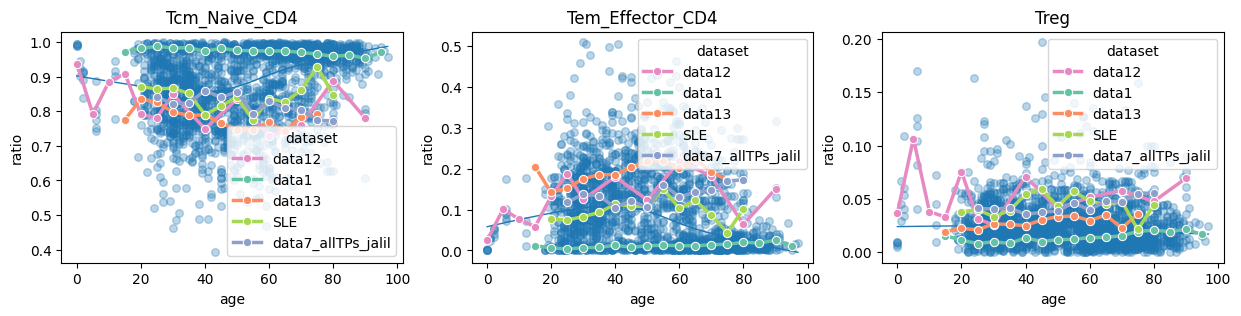

In [14]:
from ciim.src.common import mapping_major_2_minor
import seaborn as sns
import matplotlib.pyplot as plt

for j, cell_type in enumerate(['CD4T']):
    subtypes = mapping_major_2_minor[cell_type]
    fig, axes = plt.subplots(1, len(subtypes), figsize=(5 * len(subtypes), 3))
    for i, subtype in enumerate(subtypes):
        ax = axes[i]
        freq = freq_df[freq_df['Sub_CT'] == subtype]
        freq['age_bin'] = (freq['age'] // 5 * 5).astype(int)  # e.g., 48 → 45, 53 → 50

        mean_ratio = (
            freq.groupby(['age_bin', 'dataset'], as_index=False)
            .agg({'ratio': 'mean'})
        )
        
        # Scatter plot with loess smoothing
        sns.regplot(data=freq, x='age', y='ratio', scatter_kws={'alpha':0.3, 's':30}, 
                    line_kws={'linewidth': 1}, lowess=True, ci=None,  ax=ax)

        # Plot the smoothed mean ratio
        sns.lineplot(data=mean_ratio, x='age_bin', y='ratio', hue='dataset', linewidth=2.5, marker='o', palette=palette_datasets, ax=ax)

        ax.set_title(subtype)

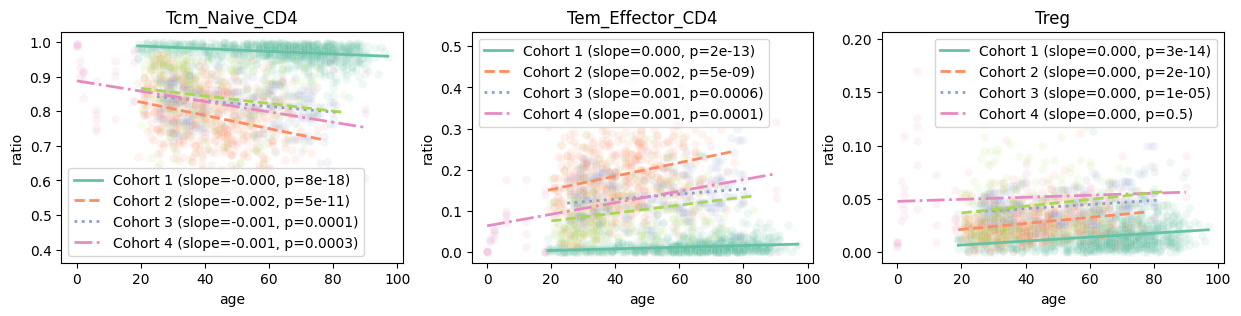

In [15]:
import statsmodels.api as sm
from scipy import stats

from ciim.src.common import mapping_major_2_minor

line_styles = ['-', '--', ':', '-.', '--', '-', '..', '-..']
for cell_type in ['CD4T']:
    subtypes = mapping_major_2_minor[cell_type]
    fig, axes = plt.subplots(1, len(subtypes), figsize=(5*len(subtypes), 3))
    for i, subtype in enumerate(subtypes):
        ax = axes[i]
        for j, dataset in enumerate(freq_df['dataset'].unique()):
            df_sub = freq_df[(freq_df['dataset'] == dataset)&(freq_df['Sub_CT'] == subtype)]
            sns.scatterplot(data=df_sub, x='age', y='ratio', color=palette_datasets[dataset], alpha=0.1, label=None, ax=ax)
            # Linear model
            X = sm.add_constant(df_sub['age'])
            model = sm.OLS(df_sub['ratio'], X).fit()
            slope = model.params['age']
            pval = model.pvalues['age']
            
            # Predict line
            x_vals = df_sub['age'].sort_values()
            y_vals = model.predict(sm.add_constant(x_vals))
            
            ax.plot(x_vals, y_vals, linestyle=line_styles[j], color=palette_datasets[dataset], label=f"{surrogate_names[dataset]} (slope={slope:.3f}, p={pval:.1g})", linewidth=2)

        ax.set_title(subtype)

# Explanatory plots

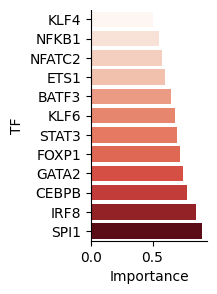

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Example data with more TFs
df = pd.DataFrame({
    'TF': ['SPI1', 'IRF8', 'CEBPB', 'GATA2', 'FOXP1', 'STAT3', 
           'KLF6', 'BATF3', 'ETS1', 'NFATC2', 'NFKB1', 'KLF4'],
    'Importance': [0.9, 0.85, 0.78, 0.75, 0.72, 0.70, 0.68, 0.65, 0.6, 0.58, 0.55, 0.5]
})

# Sort values for better visualization
df = df.sort_values(by='Importance', ascending=True)

# Create color gradient based on importance
norm = plt.Normalize(df['Importance'].min(), df['Importance'].max())
colors = sns.color_palette("Reds", as_cmap=True)(norm(df['Importance']))

# Plot
plt.figure(figsize=(1.5, 3))
ax = sns.barplot(data=df, y='TF', x='Importance', palette=colors)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Importance')
plt.ylabel('TF')
# plt.title('Robust predictors of age')

plt.show()